In [108]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
import os
import seaborn as sns
import matplotlib.pyplot as plt

parent_path = "C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps"

FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])
rul_df['unit_number'] = rul_df.index + 1 # 엔진 번호(1부터 시작) 추가

# 1. Train 데이터의 RUL 계산 및 Clipping 적용
# 각 엔진별로 현재 사이클에서 남은 수명을 계산합니다.
train_df['max_cycle'] = train_df.groupby('unit_number')['time_in_cycles'].transform('max')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']

# 사용자가 요청하신 125 Clipping 적용
# 125보다 큰 값은 모두 125로 고정합니다.
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# 불필요해진 max_cycle 삭제
train_df.drop(['max_cycle'], axis=1, inplace=True)

# 2. 데이터 타입 통일 (학습 효율 및 에러 방지)
feature_cols = [c for c in train_df.columns if c not in ['unit_number', 'time_in_cycles', 'RUL']]
train_df[feature_cols] = train_df[feature_cols].astype('float32')

# 3. AutoGluon TimeSeries 형식으로 변환
# time_in_cycles를 '진짜 날짜'처럼 인식시키기 위해 pd.to_datetime을 활용
train_df['timestamp'] = pd.to_datetime(train_df['time_in_cycles'], unit='D')

train_data = TimeSeriesDataFrame.from_data_frame(
    train_df,
    id_column="unit_number",
    timestamp_column="timestamp"
)

# 불필요해진 원래의 time_in_cycles 컬럼이 데이터 안에 남아있다면 제거
if 'time_in_cycles' in train_data.columns:
    train_data = train_data.drop(columns=['time_in_cycles'])

print(f"데이터 변환 완료 (Max RUL: {train_data['RUL'].max()})")
print(train_data.head())

Train path: C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps\train_FD001.txt
데이터 변환 완료 (Max RUL: 125)
                    op_setting_1  op_setting_2  op_setting_3    sensor_1  \
item_id timestamp                                                          
1       1970-01-02       -0.0007       -0.0004         100.0  518.669983   
        1970-01-03        0.0019       -0.0003         100.0  518.669983   
        1970-01-04       -0.0043        0.0003         100.0  518.669983   
        1970-01-05        0.0007        0.0000         100.0  518.669983   
        1970-01-06       -0.0019       -0.0002         100.0  518.669983   

                      sensor_2     sensor_3     sensor_4  sensor_5   sensor_6  \
item_id timestamp                                                               
1       1970-01-02  641.820007  1589.699951  1400.599976     14.62  21.610001   
        1970-01-03  642.150024  1591.819946  1403.140015     14.62  21.610001   
        1970-01-04  642.349976  

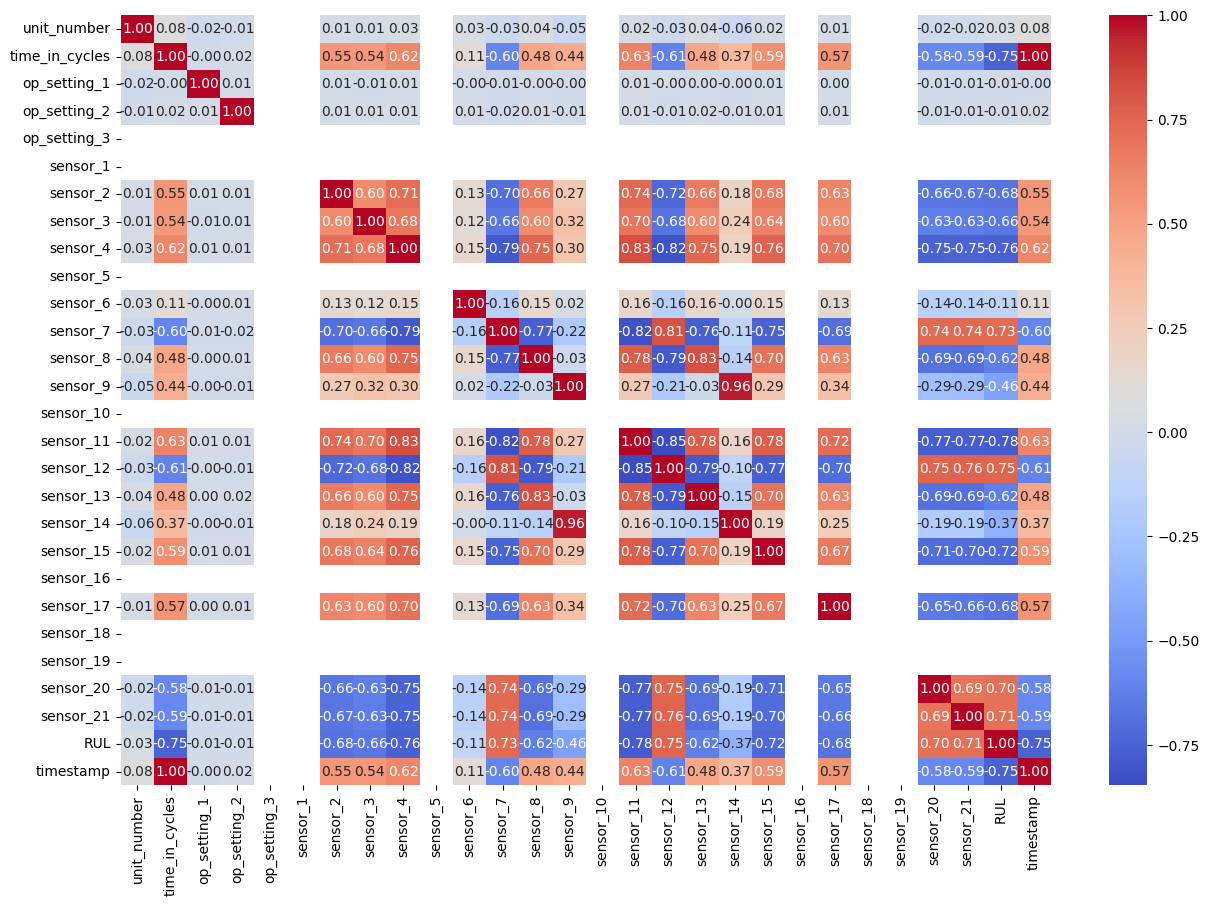

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [110]:
# 3. 컬럼명 변경 (Rename)
rename_dict = {
    "op_setting_1": "Alt[kft]", "op_setting_2": "Mn[-]", "op_setting_3": "TLA[deg]",
    "sensor_1": "T2[R]", "sensor_2": "T24[R]", "sensor_3": "T30[R]", "sensor_4": "T50[R]",
    "sensor_5": "P2[psi]", "sensor_6": "P15[psi]", "sensor_7": "P30[psi]", "sensor_8": "Nf[rpm]",
    "sensor_9": "Nc[rpm]", "sensor_10": "epr[-]", "sensor_11": "phi[pph/psi]", "sensor_12": "Ps30[psi]",
    "sensor_13": "NRf[rpm]", "sensor_14": "NRc[rpm]", "sensor_15": "BPR[-]", "sensor_16": "farB[-]",
    "sensor_17": "htBleed[]", "sensor_18": "Nf_dmd[rpm]", "sensor_19": "PCNfR_dmd[Pct]",
    "sensor_20": "W31[lbm/s]", "sensor_21": "W32[lbm/s]",
}
train_df = train_df.rename(columns=rename_dict)
test_df = test_df.rename(columns=rename_dict)

# 4. 수치 정규화 (Rounding)
def clean_round(series, ndigits=4, eps=1e-6):
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

target_cols = [col for col in rename_dict.values() if col in train_df.columns]
for col in target_cols:
    train_df[col] = clean_round(train_df[col], ndigits=4)
    test_df[col] = clean_round(test_df[col], ndigits=4)

In [111]:
# [Train 처리]
# 1. time_in_cycles를 제외 리스트에서 뺍니다 (피처로 쓰기 위해)
exclude_train = ['unit_number', 'RUL', 'timestamp'] # time_in_cycles를 여기서 제거
feature_cols_train = [c for c in train_df.columns if c not in exclude_train]
train_df[feature_cols_train] = train_df[feature_cols_train].astype('float32')

# 2. timestamp 생성
train_df['timestamp'] = pd.to_datetime(train_df['time_in_cycles'], unit='D')
train_data = TimeSeriesDataFrame.from_data_frame(
    train_df,
    id_column="unit_number",
    timestamp_column="timestamp"
)

# [Test 처리]
exclude_test = ['unit_number', 'timestamp'] # 여기도 동일하게 수정
feature_cols_test = [c for c in test_df.columns if c not in exclude_test]
test_df[feature_cols_test] = test_df[feature_cols_test].astype('float32')

test_df['timestamp'] = pd.to_datetime(test_df['time_in_cycles'], unit='D')
test_data = TimeSeriesDataFrame.from_data_frame(
    test_df,
    id_column="unit_number",
    timestamp_column="timestamp"
)

print("전처리 완료! 이제 cycle 정보가 피처로 포함되었습니다.")

전처리 완료! 이제 cycle 정보가 피처로 포함되었습니다.


In [112]:
# 1. 피처 엔지니어링 함수 정의 (한 번만 작성)
def apply_feature_engineering(df):
    # 계산 로직 (중복 방지를 위해 함수 내부에 집중)
    df["P50[psi]"] = df["epr[-]"] * df["P2[psi]"]
    df["Fan.PR[-]"] = df["P15[psi]"] / df["P2[psi]"]
    df["LPC.TR[-]"] = df["T24[R]"] / df["T2[R]"]
    df["HPC.TR[-]"] = df["T30[R]"] / df["T24[R]"]
    df["OPR[-]"] = df["P30[psi]"] / df["P2[psi]"]
    df["Wf[pph]"] = df["phi[pph/psi]"] * df["Ps30[psi]"]
    df["Wa36[lbm/s]"] = df["Wf[pph]"] / 3600.0 / df["farB[-]"]
    df["W24[lbm/s]"] = df["Wa36[lbm/s]"] + df["W31[lbm/s]"] + df["W32[lbm/s]"]
    df["W15[lbm/s]"] = df["W24[lbm/s]"] * df["BPR[-]"]
    df["W2[lbm/s]"] = df["W15[lbm/s]"] + df["W24[lbm/s]"]
    df["WfP3C[pph/psi]"] = df["phi[pph/psi]"] / np.sqrt(df["T2[R]"] / 518.67)
    return df

# 2. Train과 Test에 각각 적용
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)

In [113]:
# 2. 피처 다이어트 (불필요한 원본/파생 컬럼 삭제) - [지금 작성하신 코드]
drop_features_renamed = [
    'Alt[kft]', 'Mn[-]', 'TLA[deg]',
    'T2[R]', 'P2[psi]', 'P15[psi]', 'epr[-]', 'farB[-]',
    'Nf_dmd[rpm]', 'PCNfR_dmd[Pct]',
    'P50[psi]'
]
train_df.drop(columns=drop_features_renamed, inplace=True, errors='ignore')
test_df.drop(columns=drop_features_renamed, inplace=True, errors='ignore')

# 3. 그 다음 이전에 만든 "4. 데이터 타입 통일 및 TimeSeries 변환" 실행
# (이제 feature_cols를 뽑을 때 불필요한 것들이 다 빠진 상태로 깔끔하게 돌아갑니다!)

In [114]:
len(test_df.columns)

27

In [115]:
len(train_df.columns)

28

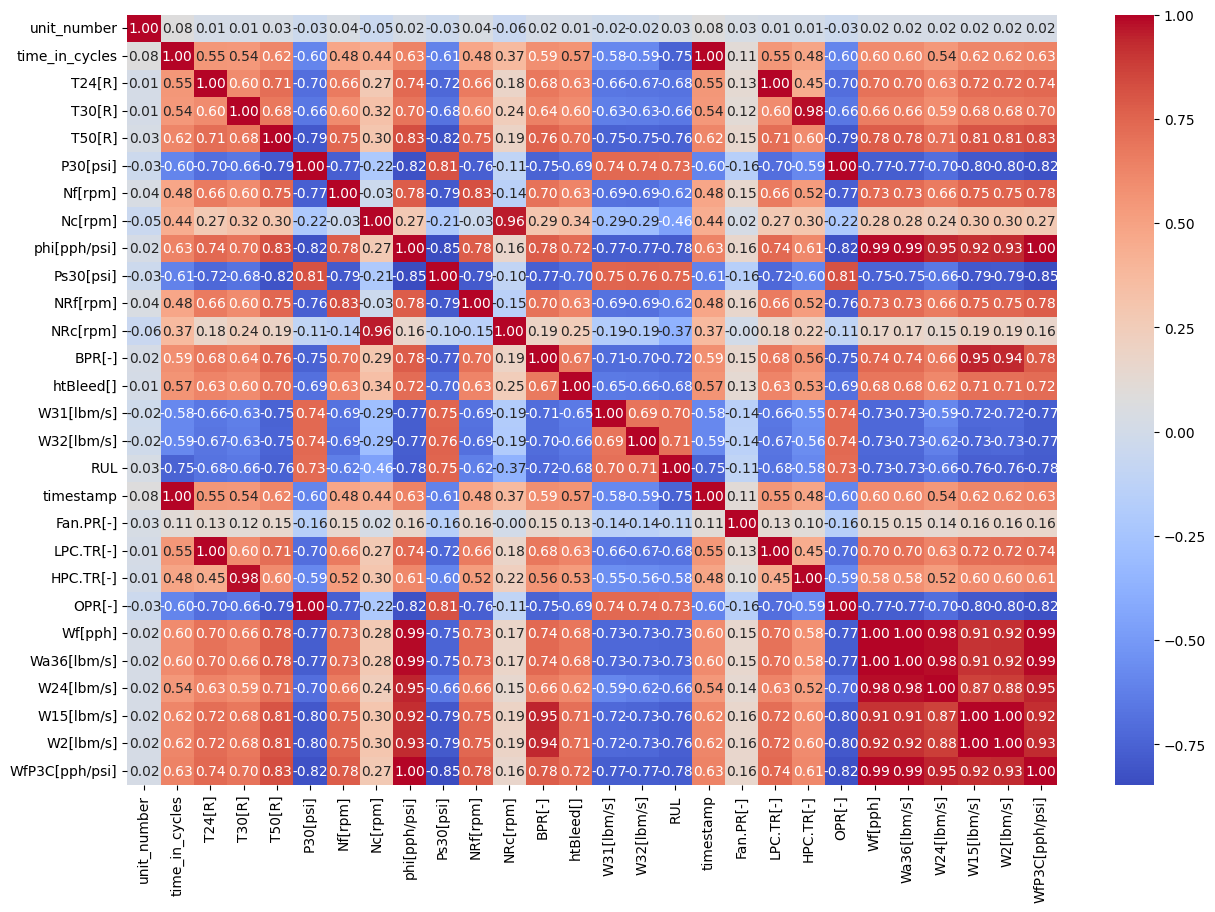

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [117]:
# 1. 수동 분할 대신 전체 데이터 준비
# (이미 전처리가 완료된 train_df를 사용한다고 가정합니다)

# 2. TimeSeriesDataFrame으로 한 번에 변환
# 수동으로 쪼개지 말고, 전체 데이터를 하나의 객체로 만듭니다.
all_train_data = TimeSeriesDataFrame.from_data_frame(
    train_df,
    id_column="unit_number",
    timestamp_column="timestamp" # 우리가 만든 날짜 형식 컬럼
)

# 3. 인덱스에 포함된 불필요한 컬럼 정리
if 'time_in_cycles' in all_train_data.columns:
    all_train_data = all_train_data.drop(columns=['time_in_cycles'])

# 4. 학습 (검증 데이터는 AutoGluon이 알아서 쪼개서 씁니다)
predictor = TimeSeriesPredictor(
    target='RUL',
    prediction_length=1,
    eval_metric="RMSE",
    freq='D'
).fit(
    all_train_data, # 쪼개지 않은 전체 데이터 전달
    presets="medium_quality",
    time_limit=600
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260205_054810"
Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to 'c:\Users\alstj\OneDrive\문서\GitHub\EST_15th_NASA\전민서\AutogluonModels\ag-20260205_054810'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          14
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       15.87 GB / 31.53 GB (50.3%)
Disk Space Avail:   114.95 GB / 450.67 GB (25.5%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'D',
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 1,
 'quantile_levels': [0.

In [118]:
# 1. 학습에 사용된 컬럼 리스트 확인 (RUL 포함 모든 피처)
# all_train_data는 TimeSeriesDataFrame이므로 columns 속성을 사용합니다.
all_features = all_train_data.columns.tolist()

# 2. test_data 구조 재정비
# 만약 test_data에 없는 컬럼이 있다면 0으로 채워넣습니다.
for col in all_features:
    if col not in test_data.columns:
        test_data[col] = 0.0

# 3. 컬럼 순서까지 train_data와 완벽하게 동일하게 정렬
# (순서가 다르면 모델이 피처를 엉뚱한 값으로 인식할 수 있습니다)
test_data = test_data[all_features]

# 4. 이제 다시 예측 수행
predictions = predictor.predict(test_data)

# 5. 결과 확인
print("예측 성공!")
print(predictions.head())

# 6. 정답(rul_df)과 비교하여 RMSE 계산
y_pred = predictions['mean'].values
y_true = rul_df['RUL'].values

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"\n최종 테스트 RMSE: {rmse:.4f}")

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


예측 성공!
                        mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                      
1       1970-02-02 -0.000829 -0.002812 -0.002131 -0.001640 -0.001221   
2       1970-02-20 -0.000838 -0.000878 -0.000864 -0.000854 -0.000846   
3       1970-05-08 -0.000843 -0.002210 -0.001741 -0.001403 -0.001114   
4       1970-04-18 -0.000838 -0.003141 -0.002350 -0.001780 -0.001293   
5       1970-04-10 -0.000843 -0.004811 -0.003449 -0.002467 -0.001628   

                         0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                     
1       1970-02-02 -0.000829 -0.000437 -0.000017  0.000474  0.001154  
2       1970-02-20 -0.000838 -0.000830 -0.000821 -0.000812 -0.000798  
3       1970-05-08 -0.000843 -0.000573 -0.000284  0.000055  0.000524  
4       1970-04-18 -0.000838 -0.000383  0.000104  0.000674  0.001465  
5       1970-04-10 -0.000843 -0.000059  0.000780  0.001762  0.

In [119]:
# '0' 대신 '125'(정상 상태)를 더미값으로 채워 모델의 오해를 방지합니다.
test_data['RUL'] = 125.0 

predictions = predictor.predict(test_data)
y_pred = predictions['mean'].values
y_true = rul_df['RUL'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"Dummy 125 설정 후 RMSE: {rmse:.4f}")

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Dummy 125 설정 후 RMSE: 64.6147


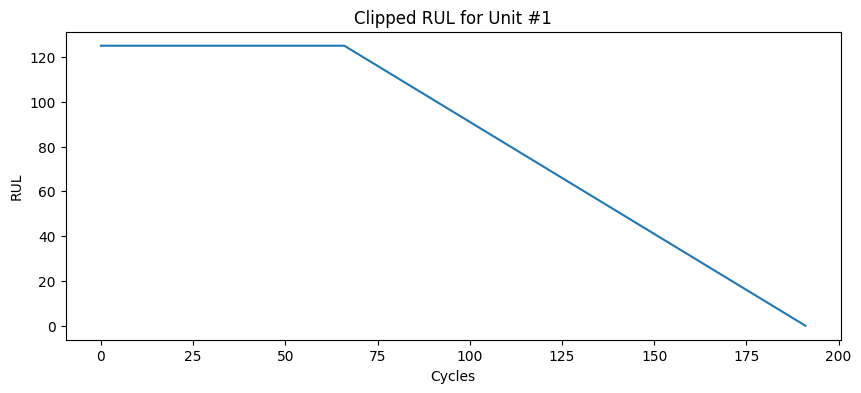

In [120]:
# 잘 적용되었는지 확인 (그래프를 그려보면 끝부분이 평평해진 것을 볼 수 있습니다)
plt.figure(figsize=(10, 4))
plt.plot(train_df[train_df['unit_number'] == 1]['RUL'])
plt.title('Clipped RUL for Unit #1')
plt.ylabel('RUL')
plt.xlabel('Cycles')
plt.show()

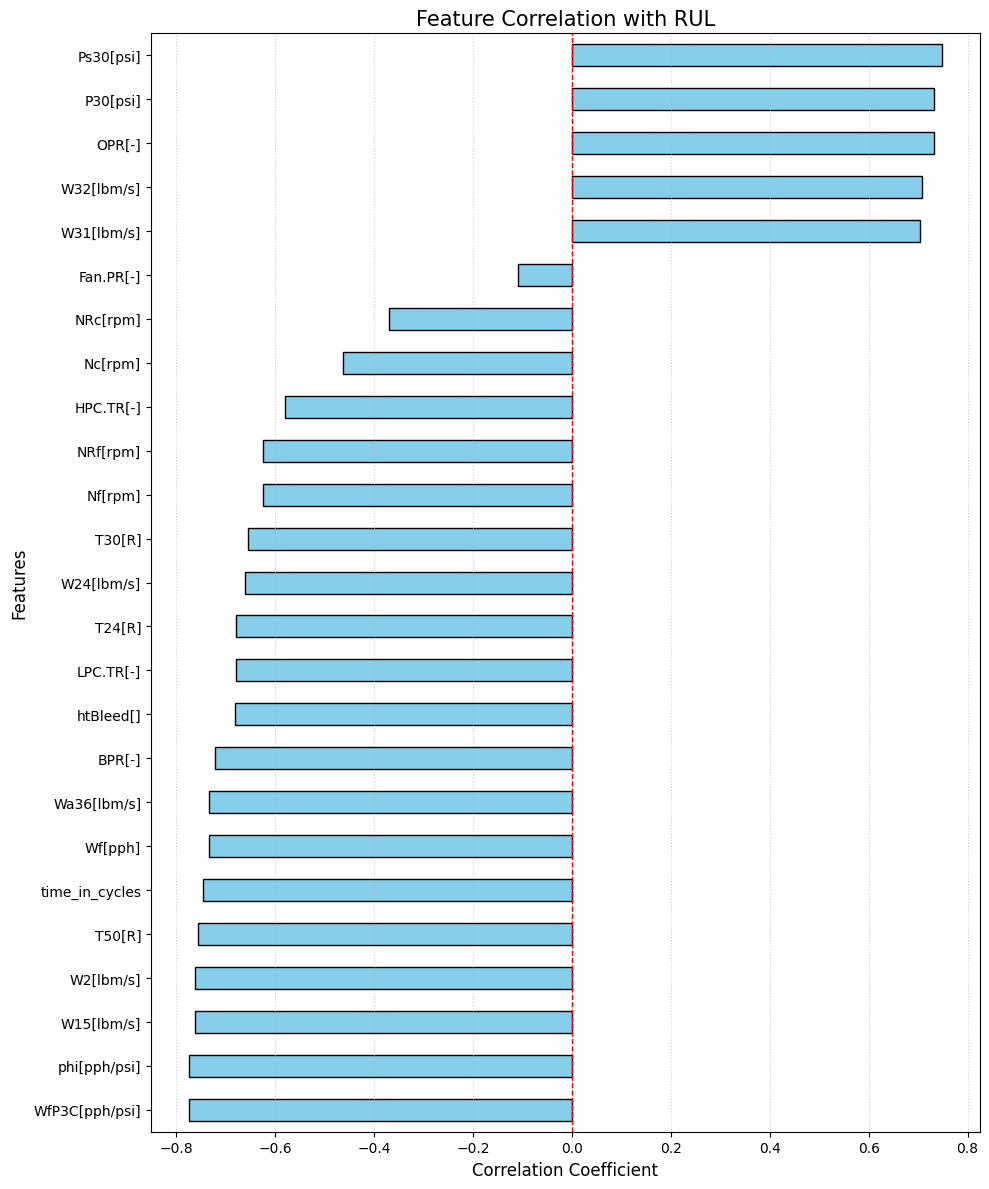

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 계산할 데이터만 준비 (condition 컬럼 등 문자열 제외)
# 숫자가 아닌 데이터는 상관관계 계산이 안 되므로 미리 제거합니다.
df_for_corr = train_df.select_dtypes(include=['number'])

# 만약 'unit_number'처럼 분석에 의미 없는 숫자 컬럼도 빼고 싶다면 아래처럼 추가로 drop 하세요.
df_for_corr = df_for_corr.drop(columns=['unit_number'], errors='ignore')

# 2. RUL과의 상관관계 계산 및 정렬
if 'RUL' in df_for_corr.columns:
    correlation = df_for_corr.corr()['RUL'].sort_values()

    # 3. 시각화 (가로 막대 그래프)
    plt.figure(figsize=(10, 12))
    
    # RUL 자기 자신은 상관관계가 1이므로 그래프에서 제외하고 그립니다.
    correlation.drop('RUL').plot(kind='barh', color='skyblue', edgecolor='black')
    
    plt.title('Feature Correlation with RUL', fontsize=15)
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1) # 0 기준선 추가
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'RUL' 컬럼이 데이터프레임에 없습니다. 앞 단계의 merge 코드를 확인해 주세요!")

In [122]:
# features 리스트에서 'RUL' 단어가 들어간 건 무조건 필터링
final_features = [f for f in features if 'RUL' not in f]

# 이제 이 final_features만 사용해서 학습합니다.
X_train_final = train_split[final_features]
X_val_final = val_split[final_features]
X_test_final = test_with_rul[final_features]

NameError: name 'features' is not defined

In [ ]:
# 1. 'RUL_rolling' 컬럼 삭제 (범인 검거 및 제거)
cols_to_drop = ['RUL_rolling']

# train, val, test 데이터에서 해당 컬럼을 제거합니다.
X_train_clean = X_train_final_scaled.drop(columns=cols_to_drop, errors='ignore')
X_val_clean = X_val_final_scaled.drop(columns=cols_to_drop, errors='ignore')
X_test_clean = X_test_final_scaled.drop(columns=cols_to_drop, errors='ignore')

print(f"삭제 후 남은 피처 수: {X_train_clean.shape[1]}")
print("RUL_rolling 제거 확인:", 'RUL_rolling' not in X_train_clean.columns)

# 2. 모델 재정의 및 학습
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

# 3. 깨끗한 데이터(X_train_clean)로 다시 학습
model.fit(
    X_train_clean, y_train,
    eval_set=[(X_val_clean, y_val)],
    verbose=50
)

# 4. 테스트 데이터 예측 (반드시 마지막 시점만 추출!)
X_test_last = X_test_clean.groupby(test_with_rul['unit_number']).last()
y_pred_raw = model.predict(X_test_last)
y_pred_xgb = np.clip(y_pred_raw, 0, 125)

# 5. 최종 성능 확인
y_test_clipped = y_test.clip(upper=125)
rmse_xgb = np.sqrt(mean_squared_error(y_test_clipped, y_pred_xgb))

print(f"\n[최종 결과] 이제 치팅 없는 진짜 RMSE: {rmse_xgb:.2f}")

삭제 후 남은 피처 수: 25
RUL_rolling 제거 확인: True
[0]	validation_0-rmse:41.36450


[50]	validation_0-rmse:27.93980
[100]	validation_0-rmse:20.75211
[150]	validation_0-rmse:17.32020
[200]	validation_0-rmse:15.83218
[250]	validation_0-rmse:15.27671
[300]	validation_0-rmse:15.14185
[340]	validation_0-rmse:15.14166

[최종 결과] 이제 치팅 없는 진짜 RMSE: 21.38


In [ ]:
# 모델 선언
predictor = TimeSeriesPredictor(
    target='RUL', 
    prediction_length=1, 
    eval_metric="RMSE"
)

# 학습 시작
predictor.fit(
    train_data,
    presets="medium_quality", # 'high_quality'로 하면 성능은 좋지만 시간이 오래 걸려요
    time_limit=600           # 10분(600초) 동안 학습. 데이터가 크면 늘려주세요.
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260205_043827"
Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to 'c:\Users\alstj\OneDrive\문서\GitHub\EST_15th_NASA\전민서\AutogluonModels\ag-20260205_043827'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          14
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       13.36 GB / 31.53 GB (42.4%)
Disk Space Avail:   115.03 GB / 450.67 GB (25.5%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 1,
 'quantile_levels': [0.1, 0.2, 0.3, 0

In [ ]:
# 2. 다시 TimeSeriesDataFrame으로 변환
from autogluon.timeseries import TimeSeriesDataFrame
test_data = TimeSeriesDataFrame.from_data_frame(
    test_df,
    id_column="unit_number",
    timestamp_column="time_in_cycles"
)

# 3. 이제 예측 수행 (에러가 나지 않을 겁니다!)
predictions = predictor.predict(test_data)

KeyError: 'RUL'

In [ ]:
# 1. 예측 수행
predictions = predictor.predict(test_data)

# 2. 결과 정리 (AutoGluon은 unit_number를 'item_id'라는 이름으로 내보냅니다)
y_pred = predictions.reset_index()

# 만약 컬럼에 'unit_number'가 없고 'item_id'가 있다면 이름을 바꿔줍니다.
if 'item_id' in y_pred.columns:
    y_pred = y_pred.rename(columns={'item_id': 'unit_number'})

# 이제 필요한 컬럼만 추출
y_pred = y_pred[['unit_number', 'mean']]

# 3. 실제 정답(rul_df)과 병합하여 성적표 작성
final_comparison = pd.merge(
    y_pred, 
    rul_df, 
    on='unit_number'
)

# 4. 정답지 Clipping (NASA 표준 125 적용)
final_comparison['RUL'] = final_comparison['RUL'].clip(upper=125)

print("--- 예측 결과 상위 5개 ---")
print(final_comparison.head())

Model not specified in predict, will default to the model with the best validation score: ETS


--- 예측 결과 상위 5개 ---
   unit_number  mean  RUL
0            1   0.0  112
1            2   0.0   98
2            3   0.0   69
3            4   0.0   82
4            5   0.0   91


In [ ]:
# 1. NASA 공식 스코어 함수 (작성하신 코드 그대로)
def nasa_scoring_function(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for diff in d:
        if diff < 0:
            # 늦은 예측 (위험): 더 큰 벌점
            score += np.exp(-diff / 13) - 1
        else:
            # 이른 예측 (비용 발생): 상대적으로 적은 벌점
            score += np.exp(diff / 10) - 1
    return score

# 2. 사용자님 변수에 맞춰 데이터 준비
# y_test_clipped 대신 실제 '정답지(RUL)'인 rul_df['RUL']을 사용하는 것이 NASA 공식 방식에 더 가깝습니다.
y_true_actual = rul_df['RUL'].values 
y_pred_final_val = y_pred_rf # 아까 만드신 0.97:0.03 앙상블 예측값

# 3. 스코어 계산
final_nasa_score = nasa_scoring_function(y_true_actual, y_pred_final_val)

print(f"--- Business Impact Analysis ---")
print(f"Final RF RMSE: {rmse_rf}") # 아까 달성하신 점수
print(f"NASA Asymmetric Score: {final_nasa_score:.2f}")

--- Business Impact Analysis ---
Final RF RMSE: 25.639706664823056
NASA Asymmetric Score: 2896.06


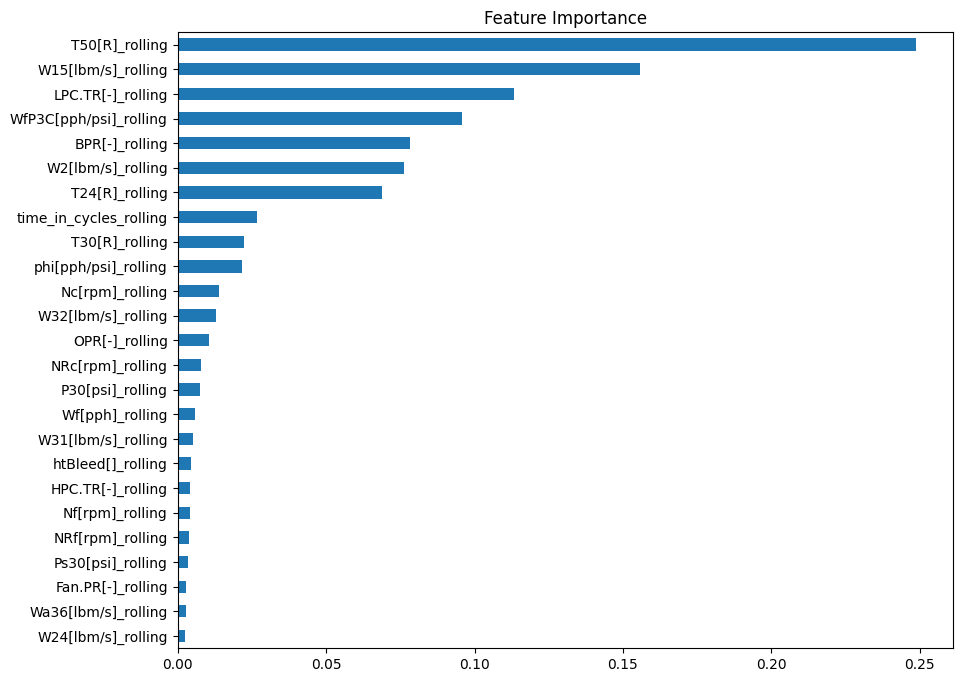

In [ ]:
import matplotlib.pyplot as plt

# 모델이 중요하다고 생각하는 순서대로 정렬
importances = pd.Series(model.feature_importances_, index=X_train_final.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance')
plt.show()

In [ ]:
# 2. 예측 수행# AutoGluon은 각 unit_number의 '마지막 시점' 이후를 예측합니다.
predictions = predictor.predict(test_data)# 3. 예측값과 실제 정답(rul_df) 비교# predictions는 각 unit의 마지막 시점 다음 값(RUL)을 담고 있습니다.
final_comparison = pd.merge(
predictions.reset_index()[['unit_number', 'mean']], # 예측된 RUL 값
rul_df, # 실제 정답 RUL
on='unit_number'
)